# Weight Uncertainty for Classification

This notebook illustrates IVON's weight uncertainty on a simple classification task.

Here we set `beta2=1.0`, which freezes the Hessian EMA at its initialization `hess_init=1.0`.
The posterior is then an isotropic Gaussian with the same uncertainty in every weight direction.

In [1]:
import torch
import matplotlib.pyplot as plt

from evon import EVON
from ivon import IVON
from sklearn.datasets import make_moons


plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"

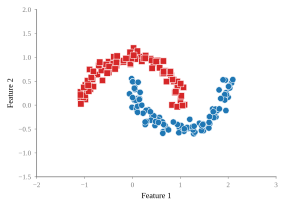

In [2]:
def plot_data(ax, X, y):
    for cls, m, c in [(0, 's', 'tab:red'), (1, 'o', 'tab:blue')]:
        ax.scatter(
            *X[y == cls].T,
            marker=m,
            color=c,
            s=40,
            edgecolors='white',
            linewidths=0.5,
            label=cls,
        )


fig, ax = plt.subplots(figsize=(5 / 1.2, 3.5 / 1.2))

torch.manual_seed(2)

X, y = make_moons(n_samples=200, noise=0.08)
X = torch.as_tensor(X, dtype=torch.float32)
y = torch.as_tensor(y, dtype=torch.float32)
plot_data(ax, X, y)

ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-2, 3), ylim=(-1.5, 2))
ax.set_aspect('equal')
plt.tight_layout()

In [3]:
class MLP(torch.nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        layers = [torch.nn.Linear(2, hidden), torch.nn.ReLU()]
        for _ in range(3):
            layers += [torch.nn.Linear(hidden, hidden), torch.nn.ReLU()]
        layers += [torch.nn.Linear(hidden, 1)]
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP()

opt = IVON(
    model.parameters(),
    lr=0.7,
    ess=5e1,
    weight_decay=1e-5,
    hess_init=1.0,
    beta1=0.9,
    beta2=1.0,
    clip_radius=0.5,
    rescale_lr=False
)

steps = 7500
loss_fn = torch.nn.BCEWithLogitsLoss()
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, eta_min=0.0, T_max=steps)

for _ in range(steps + 1):
    with opt.sampled_params(train=True):
        opt.zero_grad()
        loss = loss_fn(model(X), y.view(-1, 1))
        loss.backward()
    opt.step()
    sched.step()

Next, we train the same network with EVON. It runs IVON in the eigenspace of the SOAP preconditioner, so its posterior covariance in weight space is not restricted to be diagonal and can capture correlations between the network's weights. Compared to the IVON cell we use a larger `ess`, a smaller `hess_init` (so the prior, not the initialization, bounds the variance in flat directions), and disable the update whitening, which would otherwise wash out the curvature information that shapes the covariance.

In [4]:
model_evon = MLP()

opt_evon = EVON(
    model_evon.parameters(),
    lr=1e-3,
    ess=3e4,
    weight_decay=1e-5,
    hess_init=4e-3,
    betas=(0.9, 0.9995),
    mc_samples=1,
    precondition_frequency=10,
    whiten_prec_grad=False,
)

sched_evon = torch.optim.lr_scheduler.CosineAnnealingLR(opt_evon, eta_min=0.0, T_max=steps)

for _ in range(steps + 1):
    with opt_evon.sampled_params(train=True):
        opt_evon.zero_grad()
        loss = loss_fn(model_evon(X), y.view(-1, 1))
        loss.backward()
    opt_evon.step()
    sched_evon.step()


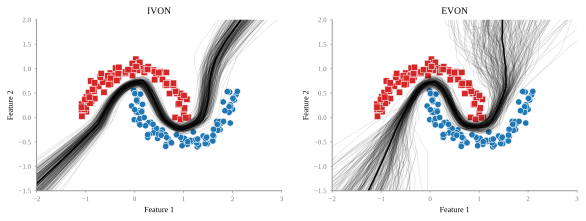

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10 / 1.2, 3.5 / 1.2))

xx, yy = torch.meshgrid(*[torch.linspace(*lim, 200) for lim in [(-2, 3), (-1.5, 2)]], indexing='xy')
grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)

for ax, opt_i, model_i, title in [(axs[0], opt, model, 'IVON'), (axs[1], opt_evon, model_evon, 'EVON')]:
    plot_data(ax, X, y)
    ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-2, 3), ylim=(-1.5, 2), title=title)

    with torch.no_grad():
        for _ in range(250):
            with opt_i.sampled_params(train=False):
                zz = model_i(grid).reshape(xx.shape)
            ax.contour(xx, yy, zz, levels=[0], colors='k', alpha=0.15, linewidths=0.5)

        zz = model_i(grid).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=[0], colors='k', linewidths=1.5)

    ax.set_aspect('equal')

plt.tight_layout()


Next, train an IVON whose Hessian estimate is learned from the data (`beta2=0.9995`). The posterior stays diagonal, but the per-coordinate variances now differ.

In [6]:
model_ivon_diag = MLP()

opt_ivon_diag = IVON(
    model_ivon_diag.parameters(),
    lr=0.02,
    ess=2e4,
    weight_decay=1e-5,
    hess_init=4e-3,
    beta1=0.9,
    beta2=0.9995,
    clip_radius=0.1,
    rescale_lr=False
)

sched_diag = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_ivon_diag,
    eta_min=0.0,
    T_max=steps,
)

for _ in range(steps + 1):
    with opt_ivon_diag.sampled_params(train=True):
        opt_ivon_diag.zero_grad()
        loss = loss_fn(model_ivon_diag(X), y.view(-1, 1))
        loss.backward()
    opt_ivon_diag.step()
    sched_diag.step()


## Posterior covariance structure

Draw the exact posterior covariance of each network on a strided subset of the parameters, ordered layer by layer. The first IVON keeps `beta2=1.0`, so its Hessian estimate stays pinned at the init and its covariance is a scaled identity; the second IVON learns its Hessian estimate (`beta2=0.9995`), so the diagonal entries differ by orders of magnitude. EVON's covariance is diagonal only in the per-layer SOAP eigenspaces, which translates to a block-diagonal structure in weight space; its Hessian EMA (`beta2=0.9995`) tracks the curvature spectrum, so the blocks carry genuine correlations between weights. The EVON panel is scaled to its largest off-diagonal entry (several times below the diagonal); each panel has its own color scale.

EVON max |off-diagonal| / max diagonal: 1.9e-02


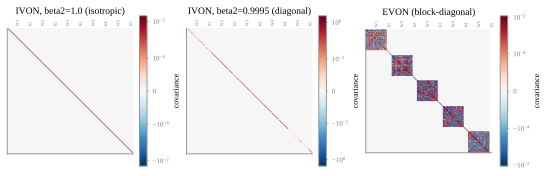

In [7]:
import torch
from matplotlib.colors import SymLogNorm

# Exact posterior covariance on a subset of parameters (72 strided weights and
# 16 strided biases per tensor), assembled block by block in layer order.
# - IVON, beta2=1.0: the Hessian estimate is pinned, so
#   sigma^2 = 1 / (ess * (hess_init + weight_decay)) is the same everywhere.
# - IVON, beta2=0.9995: sigma^2_i = 1 / (ess * (hess_i + weight_decay)) per
#   coordinate, learned from the data.
# - EVON weights: Cov(W_ab, W_cd) = sum_kl Q0[a,k] Q0[c,k] S2[k,l] Q1[b,l] Q1[d,l]
#   with S2 = 1 / (ess * (h_mom + weight_decay)) in the preconditioner eigenspace.
# - EVON biases: 1-D tensors are not preconditioned, so they stay diagonal.
def posterior_cov_blocks(module, opt, kind, n_w=72, n_b=16):
    blocks = []
    offset = 0
    for name, p in module.named_parameters():
        numel = p.numel()
        if kind == "ivon":
            g = opt.param_groups[0]
            std = (g["ess"] * (g["hess"] + g["weight_decay"])).rsqrt()
            idx = torch.linspace(0, numel - 1, steps=(n_w if p.ndim == 2 else n_b)).long()
            blocks.append(torch.diag(std[offset + idx] ** 2))
        else:
            state = opt.state[p]
            g = opt.param_groups[0]
            s2 = 1.0 / (g["ess"] * (state["h_mom"] + g["weight_decay"]))
            if p.ndim == 1:
                idx = torch.linspace(0, numel - 1, steps=min(n_b, numel)).long()
                blocks.append(torch.diag(s2[idx]))
            else:
                Q0, Q1 = state["Q"][0].float(), state["Q"][1].float()
                out_f, in_f = p.shape
                rows = torch.linspace(0, out_f - 1, steps=min(n_w, out_f)).long()
                cols = torch.linspace(0, in_f - 1, steps=min(n_w, in_f)).long()
                aa, bb = torch.meshgrid(rows, cols, indexing="ij")
                keep = torch.linspace(0, aa.numel() - 1, steps=n_w).long()
                aa, bb = aa.reshape(-1)[keep], bb.reshape(-1)[keep]
                T = Q0[aa].unsqueeze(2) * Q1[bb].unsqueeze(1)
                blocks.append(torch.einsum("kl,akl,bkl->ab", s2, T, T))
        offset += numel
    return blocks


blocks_iso = posterior_cov_blocks(model, opt, "ivon")
blocks_diag = posterior_cov_blocks(model_ivon_diag, opt_ivon_diag, "ivon")
blocks_evon = posterior_cov_blocks(model_evon, opt_evon, "evon")
cov_iso = torch.block_diag(*blocks_iso)
cov_diag = torch.block_diag(*blocks_diag)
cov_evon = torch.block_diag(*blocks_evon)

panels = [
    (cov_iso, "IVON, beta2=1.0 (isotropic)"),
    (cov_diag, "IVON, beta2=0.9995 (diagonal)"),
    (cov_evon, "EVON (block-diagonal)"),
]

ticks, tickvals = [], []
n = 0
for j, Cb in enumerate(blocks_iso):
    n += Cb.shape[0]
    ticks.append(n - Cb.shape[0] / 2)
    tickvals.append(f"{'W' if j % 2 == 0 else 'b'}{j // 2 + 1}")
# Per-panel color scales, so each structure stays visible. The EVON panel
# excludes its diagonal when choosing the scale: its strongest correlations are
# still several times smaller than the largest variance, so the
# diagonal would otherwise wash the block structure out.
def panel_norm(C, offdiag_only=False):
    M = C.clone()
    if offdiag_only:
        M.fill_diagonal_(0)
    vmax = M.abs().max().item()
    return SymLogNorm(linthresh=vmax * 1e-3, vmin=-vmax, vmax=vmax)


off_evon = cov_evon.clone()
off_evon.fill_diagonal_(0)
print(
    "EVON max |off-diagonal| / max diagonal: "
    f"{(off_evon.abs().max() / cov_evon.diag().max()):.1e}"
)

norms = [
    panel_norm(cov_iso),
    panel_norm(cov_diag),
    panel_norm(cov_evon, offdiag_only=True),
]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.7), layout="constrained")
for ax, (C, title), norm in zip(axes, panels, norms):
    im = ax.imshow(C.numpy(), cmap="RdBu_r", norm=norm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(ticks, tickvals, fontsize=4.5, rotation=90)
    ax.tick_params(length=0, pad=2)
    ax.xaxis.set_ticks_position("top")
    ax.set_yticks([])
    # sparse colorbar ticks: stride two decades, stop above linthresh so the
    # labels stay clear of each other and of the 0 tick
    decade = 10 ** torch.floor(torch.log10(torch.tensor(norm.vmax))).item()
    cb_ticks = []
    while decade > norm.linthresh:
        cb_ticks.extend([decade, -decade])
        decade *= 1e-2
    cb_ticks.append(0)
    cb = fig.colorbar(im, ax=ax, shrink=0.8, ticks=sorted(cb_ticks))
    cb.set_label("covariance")


## Per-layer covariance structure

The same three posteriors, one row per weight matrix, on strided entry subsets of each layer. Each panel has its own color scale. Unlike the full-matrix view above, the EVON panels here keep the diagonal in the color scale: within a single layer the correlations reach at most ~10% of the variances (and their bulk far less), so scaling to the largest off-diagonal entry would saturate the panel with weak noise and clip the diagonal. Biases are omitted: as 1-D tensors they are diagonal for all three posteriors.

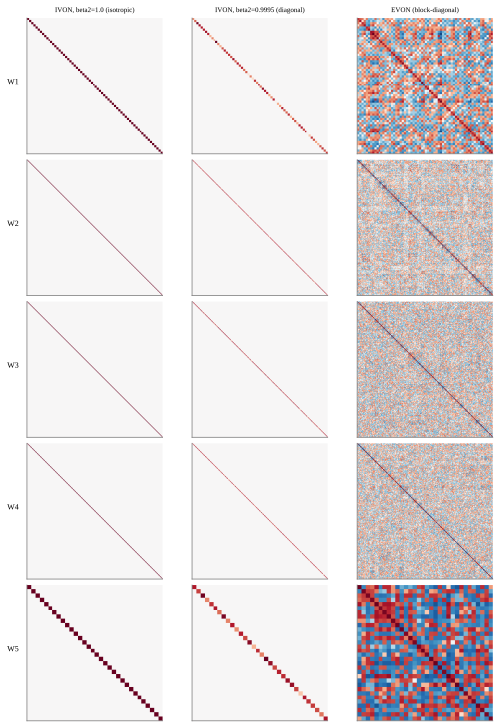

In [8]:
def layer_cov_ivon(p, opt, offset, n_side=32):
    g = opt.param_groups[0]
    var = 1.0 / (g["ess"] * (g["hess"] + g["weight_decay"]))
    out_f, in_f = p.shape
    rows = torch.linspace(0, out_f - 1, steps=min(n_side, out_f)).long()
    cols = torch.linspace(0, in_f - 1, steps=min(n_side, in_f)).long()
    aa, bb = torch.meshgrid(rows, cols, indexing="ij")
    flat = aa.reshape(-1) * in_f + bb.reshape(-1) + offset
    return torch.diag(var[flat])


def layer_cov_evon(p, opt, n_side=32):
    state = opt.state[p]
    g = opt.param_groups[0]
    s2 = 1.0 / (g["ess"] * (state["h_mom"] + g["weight_decay"]))
    Q0, Q1 = state["Q"][0].float(), state["Q"][1].float()
    out_f, in_f = p.shape
    rows = torch.linspace(0, out_f - 1, steps=min(n_side, out_f)).long()
    cols = torch.linspace(0, in_f - 1, steps=min(n_side, in_f)).long()
    aa, bb = torch.meshgrid(rows, cols, indexing="ij")
    aa, bb = aa.reshape(-1), bb.reshape(-1)
    T = Q0[aa].unsqueeze(2) * Q1[bb].unsqueeze(1)
    return torch.einsum("kl,akl,bkl->ab", s2, T, T)


# The two IVONs and EVON own separate parameter objects, so keep one weight
# list per network; the architectures match, so row r corresponds across lists.
layers, offset = [], 0
for name, p in model.named_parameters():
    if p.ndim == 2:
        layers.append((name, p, offset))
    offset += p.numel()
layers_evon = [p for p in model_evon.parameters() if p.ndim == 2]

titles = [
    "IVON, beta2=1.0 (isotropic)",
    "IVON, beta2=0.9995 (diagonal)",
    "EVON (block-diagonal)",
]

fig, axes = plt.subplots(
    len(layers), 3,
    figsize=(7.0, 2.0 * len(layers)),
    layout="constrained",
)
for r, (name, p, off) in enumerate(layers):
    covs = [
        layer_cov_ivon(p, opt, off),
        layer_cov_ivon(p, opt_ivon_diag, off),
        layer_cov_evon(layers_evon[r], opt_evon),
    ]
    # per-panel scales, diagonal included: within one layer the largest
    # correlations are only a fraction of the variances, so dropping the
    # diagonal (as the full-matrix view does) would stretch the scale onto
    # the weak off-diagonal noise instead
    norms = [panel_norm(C) for C in covs]
    for c, (C, norm) in enumerate(zip(covs, norms)):
        ax = axes[r, c]
        ax.imshow(C.numpy(), cmap="RdBu_r", norm=norm, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
    axes[r, 0].set_ylabel(f"W{r + 1}", rotation=0, labelpad=14)
for c, t in enumerate(titles):
    axes[0, c].set_title(t, fontsize=7)
